# **Desarrollo de Actividad 3 - Curso de Análisis estadístico para modelos no supervisados**


**Proyecto:** Explorando relaciones entre categorias.

**Presentado por:**

•	Adriana Patricia Rodriguez Toloza

**Fecha:** 20 de mayo de 2026

## **Selección del conjunto de datos y comprensión del contexto:**

Para el desarrollo de la actividad se selecciono como base de datos el registro de llamadas al 123 de Bogotá, disponible en la plataforma de Datos Abiertos. Esta base de datos contiene el registro de 127314 llamadas comprendidas entre el periodo de enero a junio del año 2019.
La base de datos contiene 13 variables caracterizadas de la siguiente forma:
o	Cuantitativas: (ID, Código de localidad, Edad, sin embargo, es leída como variable tipo string al presentar valores del tipo “Sin dato”.)
•	Cualitativas:
o	Nominal: Localidad, Género, Red, Tipo de incidente y Clasificación final
o	Ordinal: Fecha de incidente, Fecha de inicio de desplazamiento del móvil, Prioridad y Mes


## **Objetivo:**

El objetivo del análisis de la base de datos es poder identificar patrones o asociaciones en las llamadas recibidas en el 123 con base en temporalidad, tipos de incidentes, prioridades y ubicación.


## **Paso 1: Cargue de información:**

### ***1.1 Importar librerias:***

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import TruncatedSVD

### ***1.2 Conectar el drive:***

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ***1.3 Lectura de bases de datos CSV:***

In [3]:
df=pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/No supervisados/Actividad 3/llamadas_123.csv")

In [4]:
df.head()

,_id,FECHA_INCIDENTE,FECHA_INICIO_DESPLAZAMIENTO_MOVIL,CODIGO LOCALIDAD,LOCALIDAD,EDAD,UNIDAD,GENERO,RED,TIPO_INCIDENTE,PRIORIDAD,MES,CLASIFICACION FINAL
0,1,2019-01 01 00:00:18,2019-01 01 00:04:37,11,Suba,SIN_DATO,SIN_DATO,SIN_DATO,Norte,Lesiones personales,ALTA,ENERO,Cancelado
1,2,2019-01 01 00:00:58,2019-01 01 00:08:06,16,Puente Aranda,SIN_DATO,SIN_DATO,SIN_DATO,Sur,Accidente de tránsito con heridos/Muertos,ALTA,ENERO,Cancelado
2,3,2019-01 01 00:04:31,2019-01 01 00:07:41,3,Santa Fe,51,Años,FEMENINO,Norte,Dolor torácico,ALTA,ENERO,Traslado
3,4,2019-01 01 00:04:51,2019-01 01 00:07:46,10,Engativá,SIN_DATO,SIN_DATO,SIN_DATO,Norte,Inconsciente/Paro Cardiorrespiratorio,ALTA,ENERO,Falsa Alarma
4,5,2019-01 01 00:08:40,2019-01 01 00:10:40,8,Kennedy,SIN_DATO,SIN_DATO,SIN_DATO,Sur,Herido con pólvora,ALTA,ENERO,Cancelado


## **Paso 2: Exploración inicial de los datos:**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127314 entries, 0 to 127313
Data columns (total 13 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   _id                                127314 non-null  int64 
 1   FECHA_INCIDENTE                    127314 non-null  object
 2   FECHA_INICIO_DESPLAZAMIENTO_MOVIL  127314 non-null  object
 3   CODIGO LOCALIDAD                   127314 non-null  int64 
 4   LOCALIDAD                          127314 non-null  object
 5   EDAD                               127314 non-null  object
 6   UNIDAD                             127314 non-null  object
 7   GENERO                             127314 non-null  object
 8   RED                                127314 non-null  object
 9   TIPO_INCIDENTE                     127314 non-null  object
 10  PRIORIDAD                          127286 non-null  object
 11  MES                                127314 non-null  

Con el método .info() es posible determinar que la base de datos contiene 127314 registros y 13 columnas.
Las 13 variables seencuentran caracterizadas de la siguiente forma:
*	Cuantitativas: (ID, Código de localidad, Edad, sin embargo, es leída como variable tipo string al presentar valores del tipo “Sin dato”.)
*	Cualitativas:
  *	Nominal: Localidad, Género, Red, Tipo de incidente y Clasificación final
  *	Ordinal: Fecha de incidente, Fecha de inicio de desplazamiento del móvil, Prioridad y Mes


### ***3.1 Identificación de registros duplicados***

In [6]:
df.duplicated().sum()

np.int64(0)

Se evidencia que no presentan registros duplicados.

### ***3.1 Exploración de variables***

In [7]:
df.columns

Index(['_id', 'FECHA_INCIDENTE', 'FECHA_INICIO_DESPLAZAMIENTO_MOVIL',
       'CODIGO LOCALIDAD', 'LOCALIDAD', 'EDAD', 'UNIDAD', 'GENERO', 'RED',
       'TIPO_INCIDENTE', 'PRIORIDAD', 'MES', 'CLASIFICACION FINAL'],
      dtype='object')

#### ***3.1.1 Localidad***

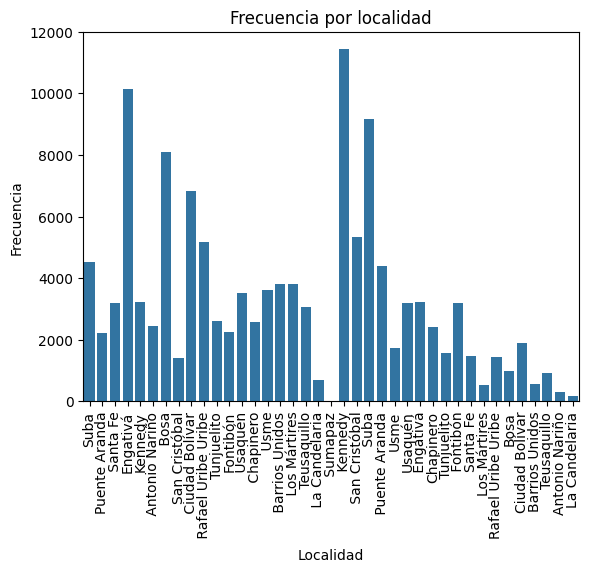

In [8]:
sns.countplot(x=df["LOCALIDAD"])
plt.title("Frecuencia por localidad")
plt.ylabel("Frecuencia")
plt.xlabel("Localidad")
plt.xticks(rotation=90)
plt.show()

#### ***3.1.1 Edad:***

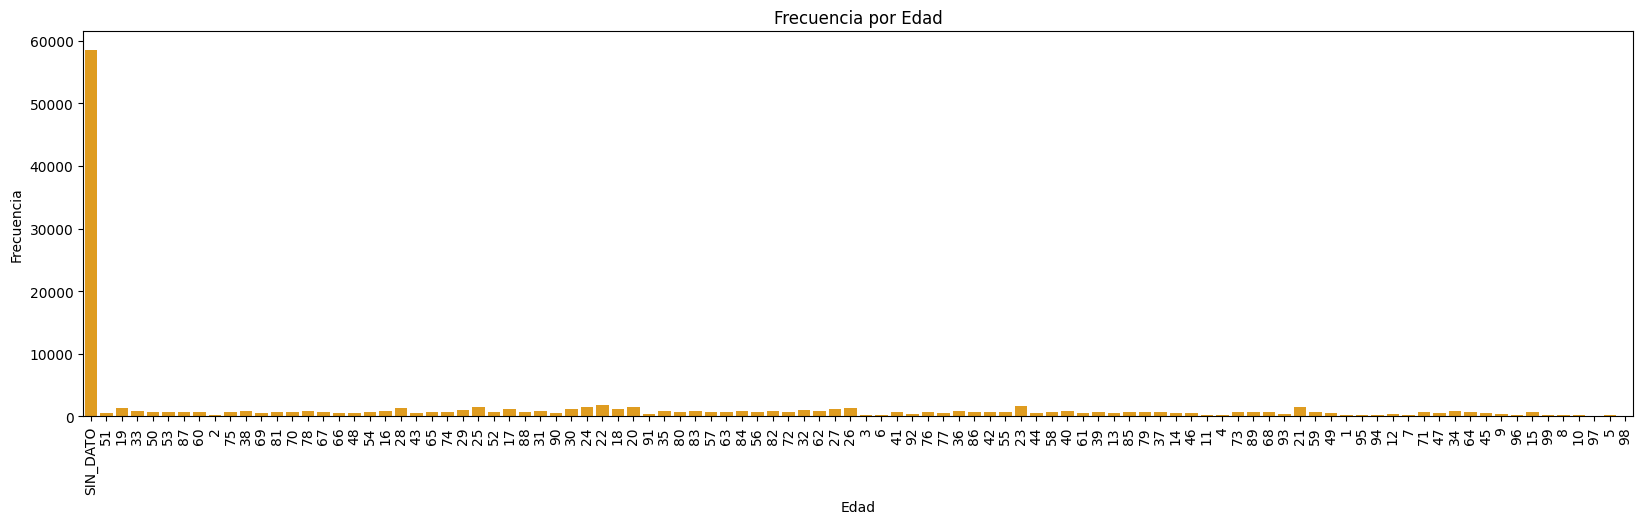

In [9]:
plt.figure(figsize=(20,5))
sns.countplot(x="EDAD",data=df,color="orange")
plt.title("Frecuencia por Edad")
plt.ylabel("Frecuencia")
plt.xlabel("Edad")
plt.xticks(rotation=90)
plt.show()

In [10]:
df["EDAD"].value_counts()

,count
EDAD,
SIN_DATO,58587
22,1787
23,1644
20,1565
24,1511
...,...
7,167
96,165
5,152


Se presentan 58587 datos ausentes en la variable edad de 127314 registros, equivalente al 46%. Por lo cual es una variable preferible a descartar.

#### ***3.1.1 Género:***

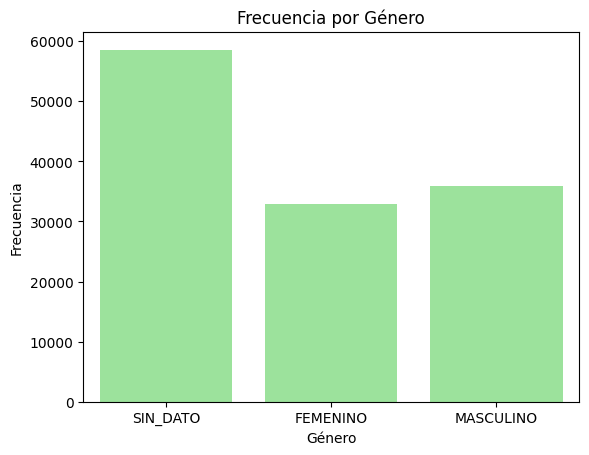

In [11]:
sns.countplot(x="GENERO", data=df,color="lightgreen")
plt.title("Frecuencia por Género")
plt.ylabel("Frecuencia")
plt.xlabel("Género")
plt.show()

In [12]:
df["GENERO"].value_counts()

,count
GENERO,
SIN_DATO,58582
MASCULINO,35882
FEMENINO,32850


Se presentan 58582 datos ausentes en la variable edad de 127314 registros, equivalente al 46%. Por lo cual es una variable preferible a descartar.

#### ***3.1.1 Red:***

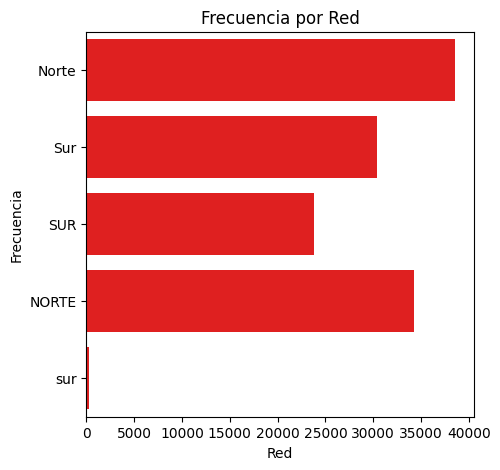

In [13]:
plt.figure(figsize=(5,5))
sns.countplot(y="RED", data=df,color="red")
plt.title("Frecuencia por Red")
plt.ylabel("Frecuencia")
plt.xlabel("Red")
plt.show()

Se encuentra la necesidad de realizar tratamiento a los niveles de esta categoria.

In [14]:
df["RED"]=df["RED"].replace("sur","SUR")
df["RED"]=df["RED"].replace("Sur","SUR")
df["RED"]=df["RED"].replace("Norte","NORTE")

#### ***3.1.1 Tipo de incidente:***

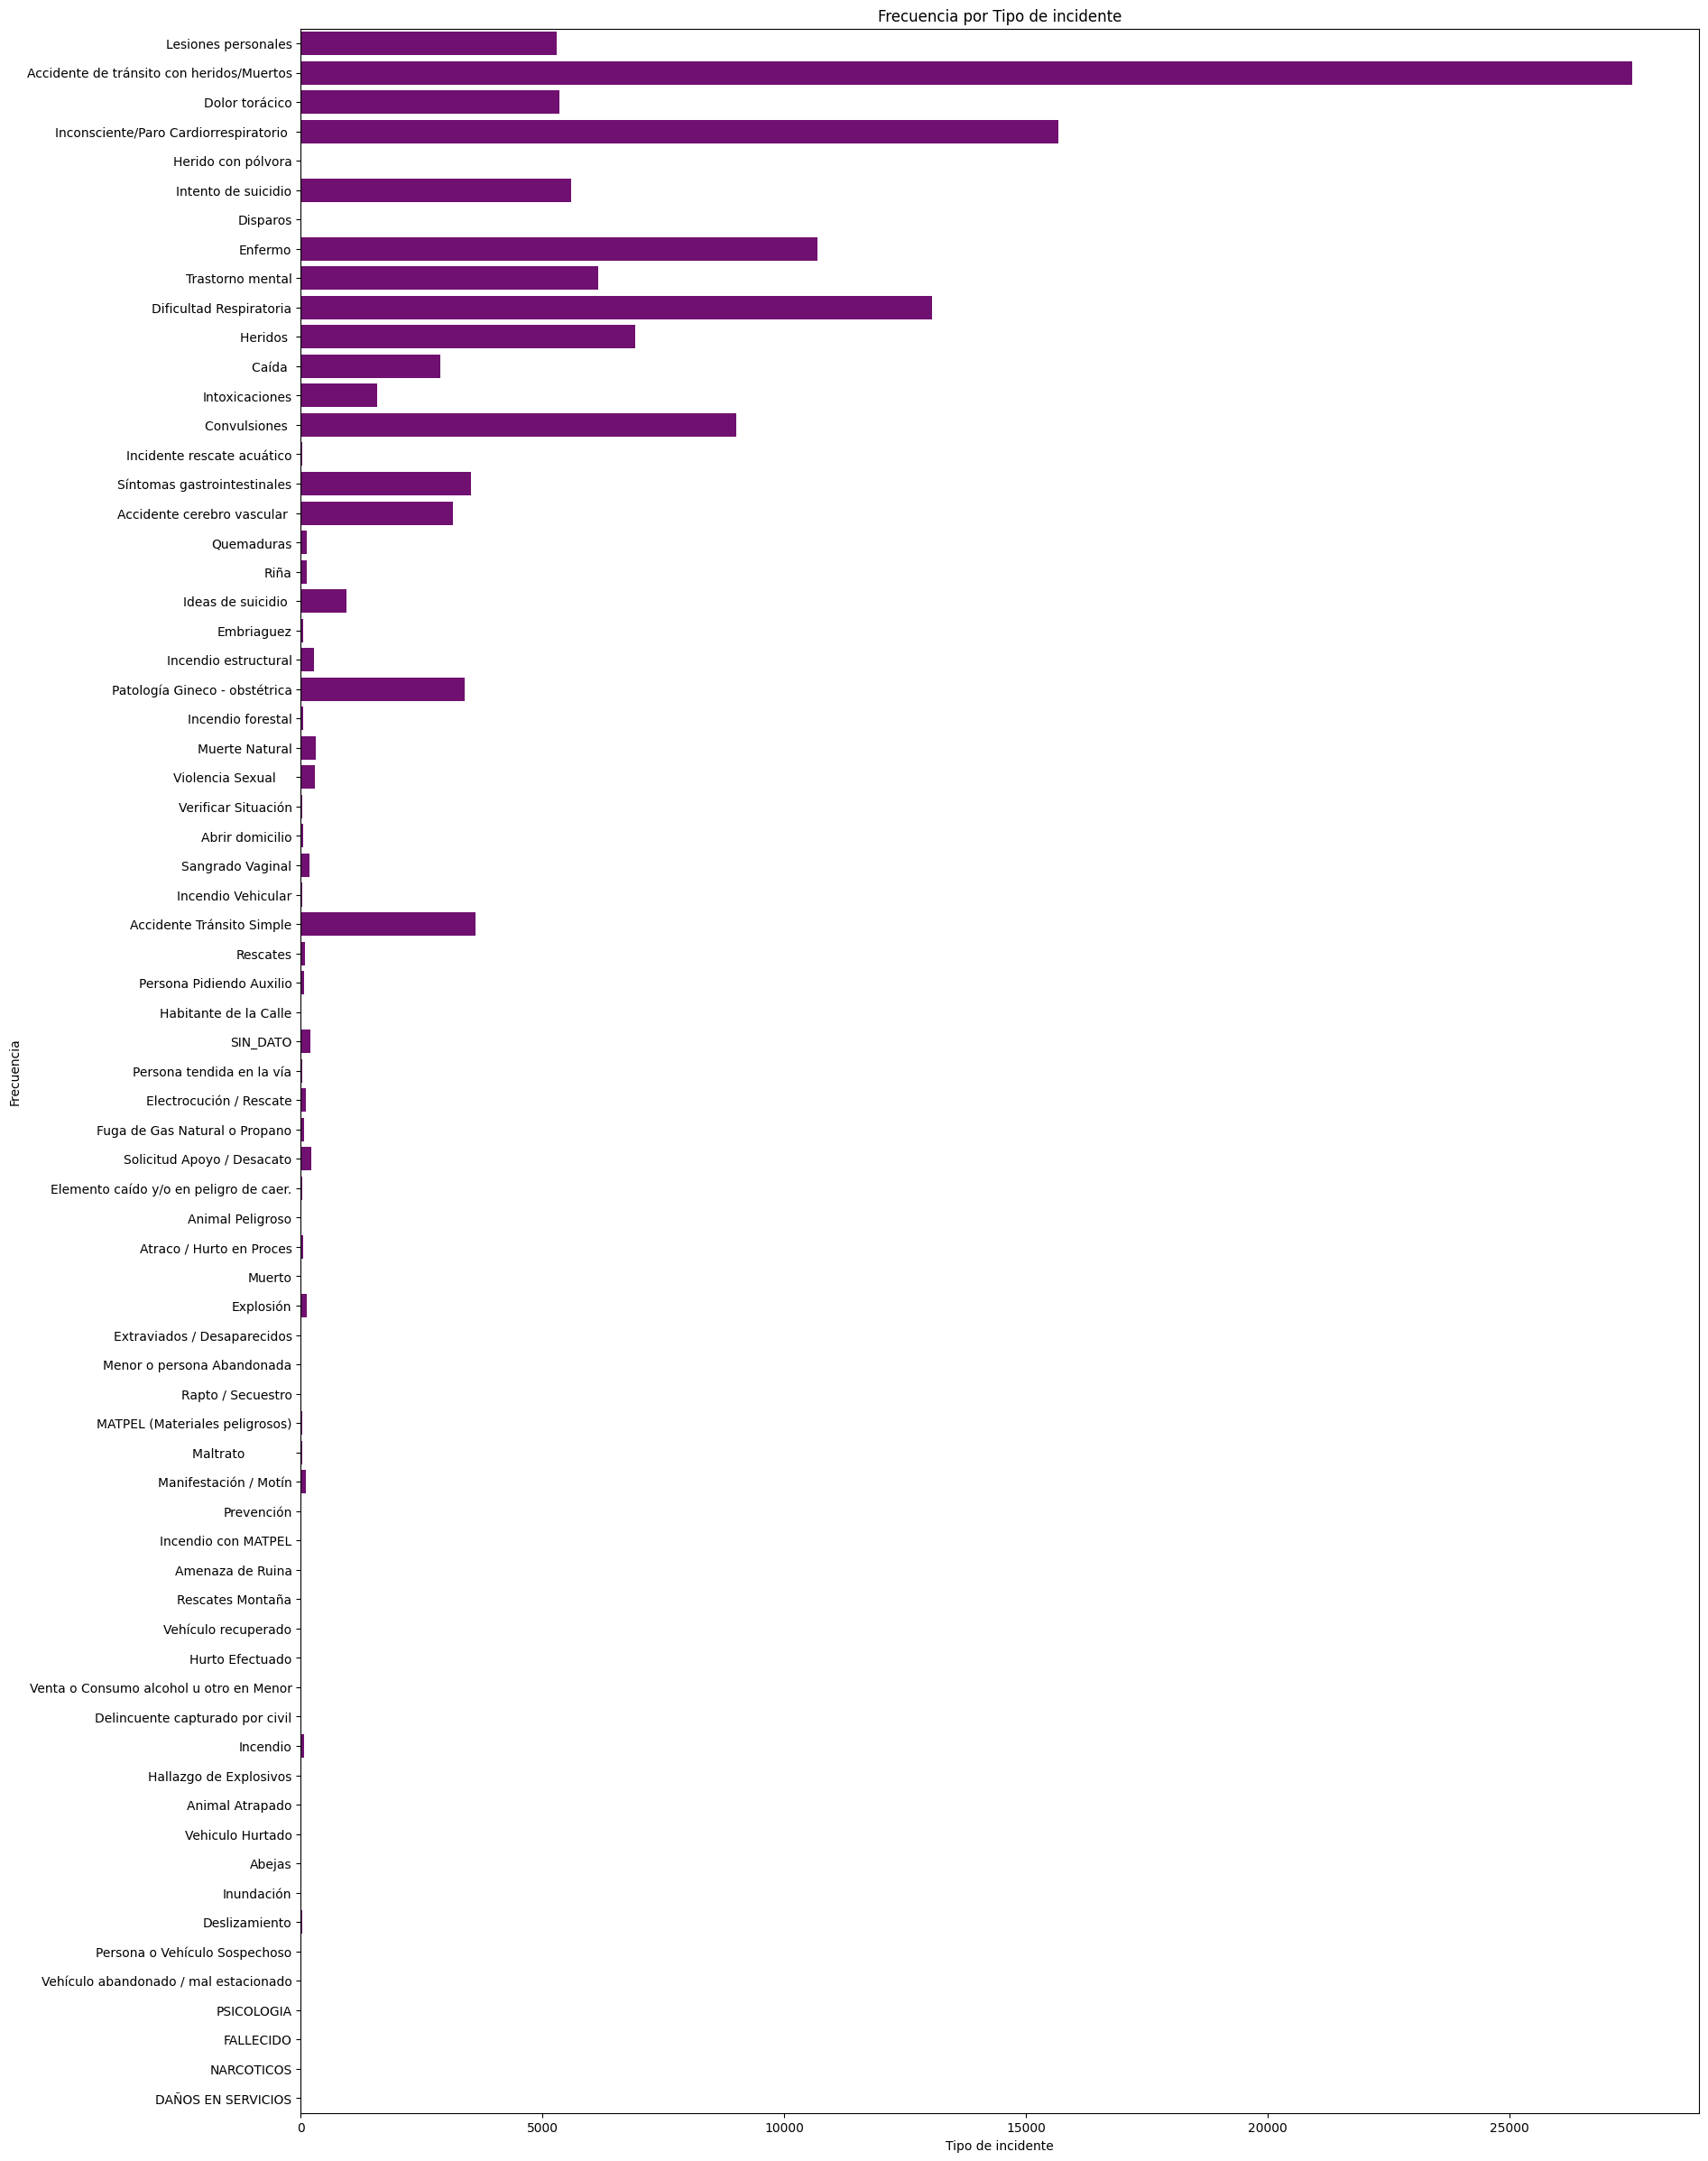

In [15]:
plt.figure(figsize=(20,30))
sns.countplot(y="TIPO_INCIDENTE", data=df,color="purple")
plt.title("Frecuencia por Tipo de incidente")
plt.ylabel("Frecuencia")
plt.xlabel("Tipo de incidente")
plt.show()

In [16]:
df["TIPO_INCIDENTE"].value_counts().head(100)

,count
TIPO_INCIDENTE,
Accidente de tránsito con heridos/Muertos,27539
Inconsciente/Paro Cardiorrespiratorio,15665
Dificultad Respiratoria,13045
Enfermo,10691
Convulsiones,8999
...,...
Vehículo abandonado / mal estacionado,2
PSICOLOGIA,2
FALLECIDO,2


In [17]:
df["TIPO_INCIDENTE"].value_counts().tail(50)

,count
TIPO_INCIDENTE,
SIN_DATO,203
Sangrado Vaginal,180
Quemaduras,133
Riña,119
Explosión,117
Manifestación / Motín,111
Electrocución / Rescate,107
Rescates,83
Fuga de Gas Natural o Propano,76


Se identifica que la variable tipo de incidente presenta 71 niveles.
Así mismo se identitfica una categoria denominada "Sin Dato" que representa un valor nulo. Se procede a analizar estos registros.

In [18]:
df[df["TIPO_INCIDENTE"]=="SIN_DATO"]

,_id,FECHA_INCIDENTE,FECHA_INICIO_DESPLAZAMIENTO_MOVIL,CODIGO LOCALIDAD,LOCALIDAD,EDAD,UNIDAD,GENERO,RED,TIPO_INCIDENTE,PRIORIDAD,MES,CLASIFICACION FINAL
2110,2111,2019-01 05 21:10:50,2019-01 05 21:11:51,8,Kennedy,SIN_DATO,SIN_DATO,SIN_DATO,SUR,SIN_DATO,ALTA,ENERO,Trasladado por Otro
2451,2452,2019-01 06 17:56:49,2019-01 06 18:43:52,6,Tunjuelito,59,Años,MASCULINO,SUR,SIN_DATO,MEDIA,ENERO,Traslado
2862,2863,2019-01 07 20:18:39,2019-01 07 20:18:55,18,Rafael Uribe Uribe,36,Años,MASCULINO,SUR,SIN_DATO,MEDIA,ENERO,Traslado
3262,3263,2019-01 08 20:47:50,2019-01 08 20:51:20,11,Suba,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,SIN_DATO,ALTA,ENERO,Cancelado
3263,3264,2019-01 08 20:47:50,2019-01 08 20:52:44,11,Suba,25,Años,MASCULINO,NORTE,SIN_DATO,ALTA,ENERO,No Amerita Traslado
...,...,...,...,...,...,...,...,...,...,...,...,...,...
126166,126167,28/06/2019 17:35,28/06/2019 17:50,9,Fontibón,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,SIN_DATO,ALTA,JUNIO,Trasladado por Otro
126469,126470,29/06/2019 8:17,29/06/2019 8:21,12,Barrios Unidos,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,SIN_DATO,0,JUNIO,Cancelado
126470,126471,29/06/2019 8:17,29/06/2019 8:18,12,Barrios Unidos,23,Años,MASCULINO,NORTE,SIN_DATO,0,JUNIO,Traslado
127204,127205,30/06/2019 18:54,30/06/2019 19:05,18,Rafael Uribe Uribe,SIN_DATO,SIN_DATO,SIN_DATO,SUR,SIN_DATO,ALTA,JUNIO,Cancelado


In [19]:
df.shape

(127314, 13)

Para la variable prioritaria "Tipo de incidente" se identifican 203 registros sin datos. Esta cifra representa el 0.13% de los datos, por lo cual no se considerarán.

Se crea una copia del dataframe donde no se incluiran los rergistros que no cuentan información de tipo de incidente.

In [20]:
df_limpio=df.copy()
df_limpio= df_limpio[df_limpio["TIPO_INCIDENTE"] != "SIN_DATO"]

In [21]:
df_limpio.shape

(127111, 13)

#### ***3.1.1 Prioridad:***

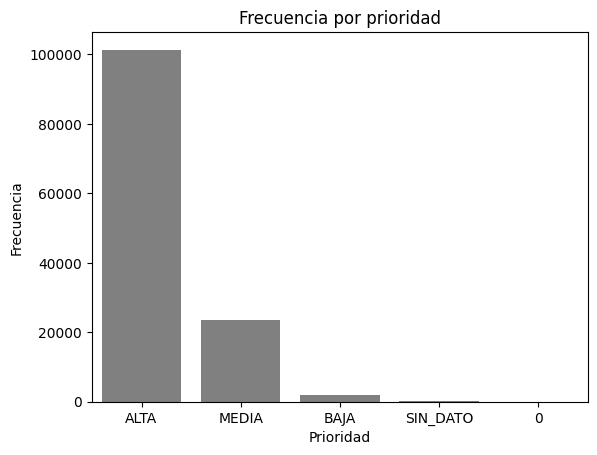

In [22]:
sns.countplot(x="PRIORIDAD", data=df_limpio,color="gray")
plt.title("Frecuencia por prioridad")
plt.ylabel("Frecuencia")
plt.xlabel("Prioridad")
plt.show()

In [23]:
df_limpio["PRIORIDAD"].value_counts()

,count
PRIORIDAD,
ALTA,101358
MEDIA,23675
BAJA,1990
SIN_DATO,65
0,23


Para la variable prioridad se identifican 23 registros nulos y 65 registros bajo el nivel "Sin dato". Se procede a eliminarlos.

In [24]:
df_limpio[df_limpio["PRIORIDAD"]=="SIN_DATO"]

,_id,FECHA_INCIDENTE,FECHA_INICIO_DESPLAZAMIENTO_MOVIL,CODIGO LOCALIDAD,LOCALIDAD,EDAD,UNIDAD,GENERO,RED,TIPO_INCIDENTE,PRIORIDAD,MES,CLASIFICACION FINAL
715,716,2019-01 02 14:14:20,2019-01 02 14:43:16,15,Antonio Nariño,43,Años,MASCULINO,SUR,Enfermo,SIN_DATO,ENERO,No Amerita Traslado
1040,1041,2019-01 03 10:40:37,2019-01 03 10:50:37,14,Los Mártires,91,Años,MASCULINO,NORTE,Síntomas gastrointestinales,SIN_DATO,ENERO,Traslado
1049,1050,2019-01 03 10:53:28,2019-01 03 11:01:20,11,Suba,22,Años,FEMENINO,NORTE,Patología Gineco - obstétrica,SIN_DATO,ENERO,Traslado
1859,1860,2019-01 05 10:16:35,2019-01 05 10:25:35,16,Puente Aranda,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,Enfermo,SIN_DATO,ENERO,Falsa Alarma
4132,4133,2019-01 11 05:47:45,2019-01 11 05:59:53,19,Ciudad Bolívar,SIN_DATO,SIN_DATO,SIN_DATO,SUR,Accidente de tránsito con heridos/Muertos,SIN_DATO,ENERO,Trasladado por Otro
...,...,...,...,...,...,...,...,...,...,...,...,...,...
104727,104728,14/05/2019 16:18,14/05/2019 16:20,1,Usaquén,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,Accidente de tránsito con heridos/Muertos,SIN_DATO,MAYO,Cancelado
107433,107434,20/05/2019 9:42,20/05/2019 9:46,6,Tunjuelito,24,Años,MASCULINO,SUR,Lesiones personales,SIN_DATO,MAYO,Traslado
108231,108232,21/05/2019 23:59,22/05/2019 0:07,8,Kennedy,SIN_DATO,SIN_DATO,SIN_DATO,SUR,Accidente de tránsito con heridos/Muertos,SIN_DATO,MAYO,Falsa Alarma
109150,109151,23/05/2019 20:27,23/05/2019 20:29,3,Santa Fe,26,Años,MASCULINO,NORTE,Accidente de tránsito con heridos/Muertos,SIN_DATO,MAYO,Desistimiento


In [25]:
df_limpio[df_limpio["PRIORIDAD"]=="0"]

,_id,FECHA_INCIDENTE,FECHA_INICIO_DESPLAZAMIENTO_MOVIL,CODIGO LOCALIDAD,LOCALIDAD,EDAD,UNIDAD,GENERO,RED,TIPO_INCIDENTE,PRIORIDAD,MES,CLASIFICACION FINAL
30178,30179,8/03/2019 8:08,8/03/2019 8:13,13,Teusaquillo,23,Años,FEMENINO,NORTE,Heridos,0,MARZO,Traslado
30812,30813,9/03/2019 13:19,9/03/2019 13:26,5,Usme,SIN_DATO,SIN_DATO,SIN_DATO,SUR,Accidente de tránsito con heridos/Muertos,0,MARZO,Cancelado
30996,30997,9/03/2019 21:08,9/03/2019 21:10,7,Bosa,44,Años,MASCULINO,SUR,Dificultad Respiratoria,0,MARZO,No Amerita Traslado
32623,32624,13/03/2019 0:05,13/03/2019 0:07,12,Barrios Unidos,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,Accidente Tránsito Simple,0,MARZO,Cancelado
33465,33466,14/03/2019 17:14,14/03/2019 17:15,19,Ciudad Bolívar,57,Años,MASCULINO,SUR,Lesiones personales,0,MARZO,Traslado
36048,36049,20/03/2019 3:02,20/03/2019 3:07,11,Suba,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,Accidente de tránsito con heridos/Muertos,0,MARZO,Cancelado
36546,36547,21/03/2019 5:15,21/03/2019 5:19,8,Kennedy,SIN_DATO,SIN_DATO,SIN_DATO,SUR,Heridos,0,MARZO,Cancelado
36547,36548,21/03/2019 5:15,21/03/2019 5:18,8,Kennedy,SIN_DATO,SIN_DATO,SIN_DATO,SUR,Heridos,0,MARZO,Cancelado
36946,36947,21/03/2019 20:39,21/03/2019 20:41,2,Chapinero,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,Accidente de tránsito con heridos/Muertos,0,MARZO,Cancelado
72737,72738,8/03/2019 8:08,8/03/2019 8:13,13,Teusaquillo,23,Años,FEMENINO,NORTE,Heridos,0,MARZO,Traslado


In [26]:
df_limpio.shape

(127111, 13)

In [27]:
df_limpio=df_limpio[df_limpio["PRIORIDAD"] != "0"]
df_limpio=df_limpio[df_limpio["PRIORIDAD"] != "SIN_DATO"] #Elimino filas  con valores no validos la columna prioridad

In [28]:
df_limpio.shape

(127023, 13)

#### ***3.1.1 Mes:***

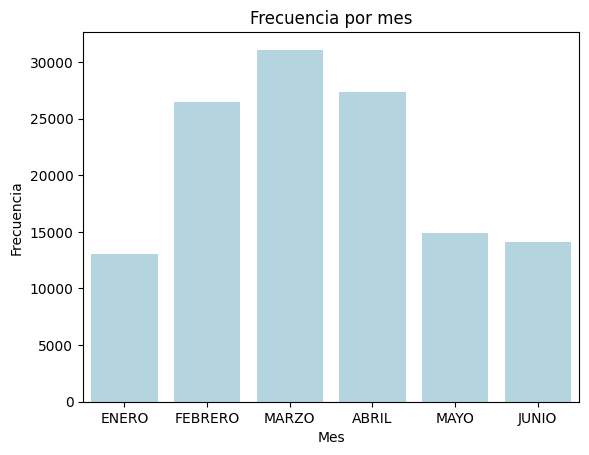

In [29]:
sns.countplot(x="MES", data=df_limpio,color="lightblue")
plt.title("Frecuencia por mes")
plt.ylabel("Frecuencia")
plt.xlabel("Mes")
plt.show()

#### ***3.1.1 Clasificación final:***

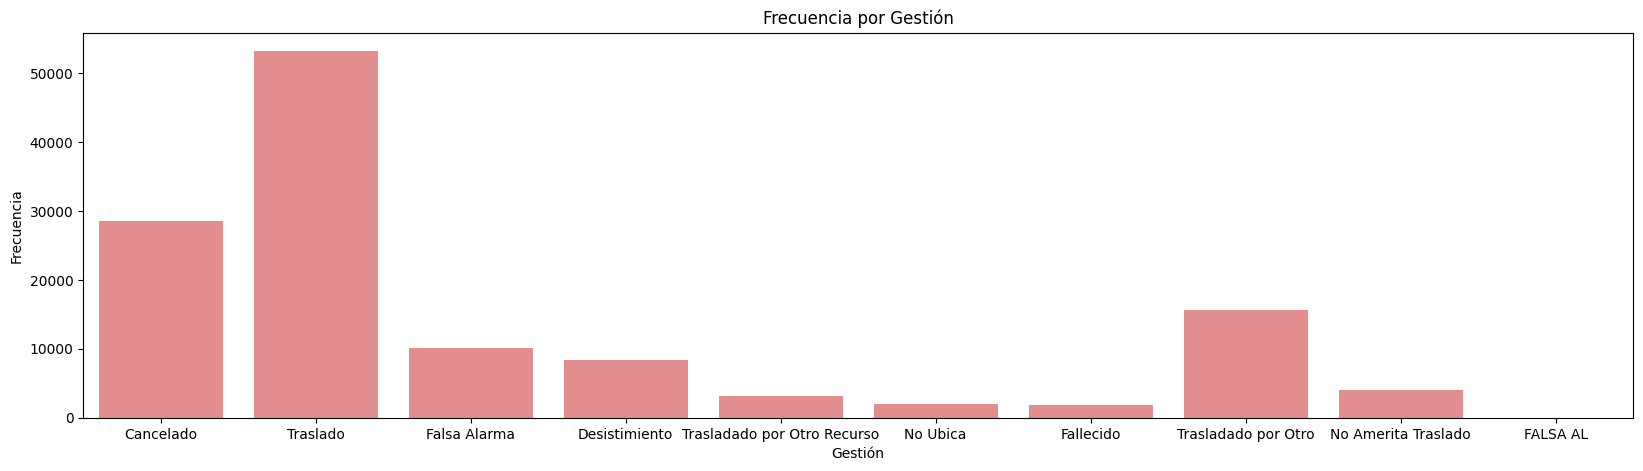

In [30]:
plt.figure(figsize=(20,5))
sns.countplot(x="CLASIFICACION FINAL", data=df_limpio,color="lightcoral")
plt.title("Frecuencia por Gestión")
plt.ylabel("Frecuencia")
plt.xlabel("Gestión")
plt.show()

In [31]:
df_limpio["CLASIFICACION FINAL"].value_counts()

,count
CLASIFICACION FINAL,
Traslado,53249
Cancelado,28571
Trasladado por Otro,15706
Falsa Alarma,10178
Desistimiento,8335
No Amerita Traslado,4037
Trasladado por Otro Recurso,3196
No Ubica,1942
Fallecido,1805


Se identifican 4 registros posiblemente erroneos y equivalentes al nivel "Falsa Alarma", por lo cual se procede a examinarlos y tratarlos.

In [32]:
df_limpio[df_limpio["CLASIFICACION FINAL"]=="FALSA AL"]

,_id,FECHA_INCIDENTE,FECHA_INICIO_DESPLAZAMIENTO_MOVIL,CODIGO LOCALIDAD,LOCALIDAD,EDAD,UNIDAD,GENERO,RED,TIPO_INCIDENTE,PRIORIDAD,MES,CLASIFICACION FINAL
16421,16422,8/02/2019 7:50,8/02/2019 7:54,6,Tunjuelito,SIN_DATO,SIN_DATO,SIN_DATO,SUR,Accidente de tránsito con heridos/Muertos,ALTA,FEBRERO,FALSA AL
18021,18022,11/02/2019 14:09,11/02/2019 14:18,11,Suba,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,Accidente de tránsito con heridos/Muertos,ALTA,FEBRERO,FALSA AL
58980,58981,8/02/2019 7:50,8/02/2019 7:54,6,Tunjuelito,SIN_DATO,SIN_DATO,SIN_DATO,SUR,Accidente de tránsito con heridos/Muertos,ALTA,FEBRERO,FALSA AL
60580,60581,11/02/2019 14:09,11/02/2019 14:18,11,Suba,SIN_DATO,SIN_DATO,SIN_DATO,NORTE,Accidente de tránsito con heridos/Muertos,ALTA,FEBRERO,FALSA AL


In [33]:
df_limpio["CLASIFICACION FINAL"]=df_limpio["CLASIFICACION FINAL"].replace("FALSA AL","Falsa Alarma")

In [34]:
df_limpio["CLASIFICACION FINAL"].value_counts()

,count
CLASIFICACION FINAL,
Traslado,53249
Cancelado,28571
Trasladado por Otro,15706
Falsa Alarma,10182
Desistimiento,8335
No Amerita Traslado,4037
Trasladado por Otro Recurso,3196
No Ubica,1942
Fallecido,1805


## **Paso 3: Agrupamiento de los datos:**

Debido a que la variable tipo de incidente presentó 70 niveles, se decidió tomar los 10 más frecuentes para realizar el análisis y marcar los demás como otros.

In [35]:
df_limpio["TIPO_INCIDENTE"].value_counts().head(10)

,count
TIPO_INCIDENTE,
Accidente de tránsito con heridos/Muertos,27513
Inconsciente/Paro Cardiorrespiratorio,15662
Dificultad Respiratoria,13036
Enfermo,10688
Convulsiones,8998
Heridos,6911
Trastorno mental,6134
Intento de suicidio,5578
Dolor torácico,5355


In [36]:
incidentes=["Accidente de tránsito con heridos/Muertos","Inconsciente/Paro Cardiorrespiratorio",
            "Dificultad Respiratoria","Enfermo","Convulsiones","Heridos","Trastorno mental",
            "Intento de suicidio","Dolor torácico","Lesiones personales"]


In [37]:
# Agrupamiento pot tipo de incidente
df_limpio["TIPO_INCIDENTE_AGRUPADO"] = df_limpio["TIPO_INCIDENTE"].apply(
    lambda x: x if x in incidentes else "Otros")

## **Paso 4: Análisis de correspondencias simples:**

Se realizó un análisis de correspondencias simples (ACS) entre las variables “Tipo de incidente agrupado” y “Mes”, mediante la construcción de una tabla de contingencia y el cálculo de frecuencias relativas. A partir de la matriz esperada bajo independencia y de los residuos estandarizados basados en la distancia chi-cuadrado, se aplicó una descomposición en valores singulares (SVD) para obtener la representación factorial de las categorías.

In [38]:
tabla_acs=pd.crosstab(df_limpio["TIPO_INCIDENTE_AGRUPADO"], df_limpio["MES"])
tabla_acs

MES,ABRIL,ENERO,FEBRERO,JUNIO,MARZO,MAYO
TIPO_INCIDENTE_AGRUPADO,,,,,,
Accidente de tránsito con heridos/Muertos,6512,3142,6396,0,7652,3811
Dificultad Respiratoria,2886,1429,2656,1501,3048,1516
Dolor torácico,1126,561,1140,595,1266,667
Enfermo,2358,1157,2280,1149,2572,1172
Intento de suicidio,1276,499,1102,605,1468,628
Lesiones personales,1032,523,1142,614,1358,624
Otros,10720,4987,10558,9021,12354,5786
Trastorno mental,1458,760,1204,661,1362,689


In [39]:
# Extraer los datos y convertirlos a matriz numpay
tabla_np = tabla_acs.values

#Calculo de frecuencia total (total de observaciones)
frec_total = tabla_np.sum()

#Calculo de frecuencias relativas (divide cada celda por el total)
probabilidad_obs=tabla_np/frec_total

#Masas de filas y columnas:
filas= probabilidad_obs.sum(axis=1) #Peso por cada fila
columnas=probabilidad_obs.sum(axis=0) #Peso por cada columna

# Matriz esperada bajo independencia
esperada = np.outer(filas, columnas)

#Matriz estandarizada
matriz_std = (probabilidad_obs - esperada) /  np.sqrt(esperada)

#Desocomposición SVD
U, s, VT = np.linalg.svd(matriz_std, full_matrices=False) #Full_matrice false haceque se eliminen columnas innecesarias o redundantes

#Coordenadas principales
F = U * s # Calculo de coordenadas factoriales de filas
G= VT.T*s #Cálcuo de coordenadas factoriales de columnas

#Inercia:
eigenvalues = s**2 #Cálculo de valores propios
inertia = (eigenvalues / eigenvalues.sum())*100 #Proporción explicada
# Varianza acumulada
cum_variance = np.cumsum(inertia)

row_coords= pd.DataFrame(
            F[:, :2],
            index=tabla_acs.index,
            columns=['Dim1', 'Dim2'])

col_coords = pd.DataFrame(
            G[:, :2],
            index=tabla_acs.columns,
            columns=['Dim1', 'Dim2'])


In [40]:
dimensiones_acs= pd.DataFrame({
           "Dimension": [f"Dim{i+1}" for i in range(len(eigenvalues))],
           "Eigenvalue": eigenvalues,
           "Inertia": inertia,
           "Varianza acumulada": cum_variance})

dimensiones_acs

,Dimension,Eigenvalue,Inertia,Varianza acumulada
0,Dim1,4.134201e-02,9.733017e+01,97.330174
1,Dim2,8.184957e-04,1.926958e+00,99.257132
2,Dim3,2.305226e-04,5.427121e-01,99.799844
3,Dim4,6.952203e-05,1.636735e-01,99.963518
4,Dim5,1.549623e-05,3.648228e-02,100.000000
5,Dim6,8.770668e-34,2.064850e-30,100.000000


In [41]:
row_coords  #Posiciones factoriales  por las filas (variable genero)


,Dim1,Dim2
TIPO_INCIDENTE_AGRUPADO,,
Accidente de tránsito con heridos/Muertos,-0.165056,0.005396
Dificultad Respiratoria,0.003843,-0.010937
Dolor torácico,-0.000360,-0.000502
Enfermo,-0.003201,-0.006480
Intento de suicidio,-0.001739,0.005759
Lesiones personales,0.002902,0.009147
Otros,0.118559,0.007115
Trastorno mental,-0.002407,-0.021449


In [42]:
col_coords #Posiciones factoriales  por las columnas (variable genero)

,Dim1,Dim2
MES,,
ABRIL,-0.029616,-0.012948
ENERO,-0.024670,-0.018789
FEBRERO,-0.028805,0.005747
JUNIO,0.191424,0.000188
MARZO,-0.035789,0.015523
MAYO,-0.033205,0.004875


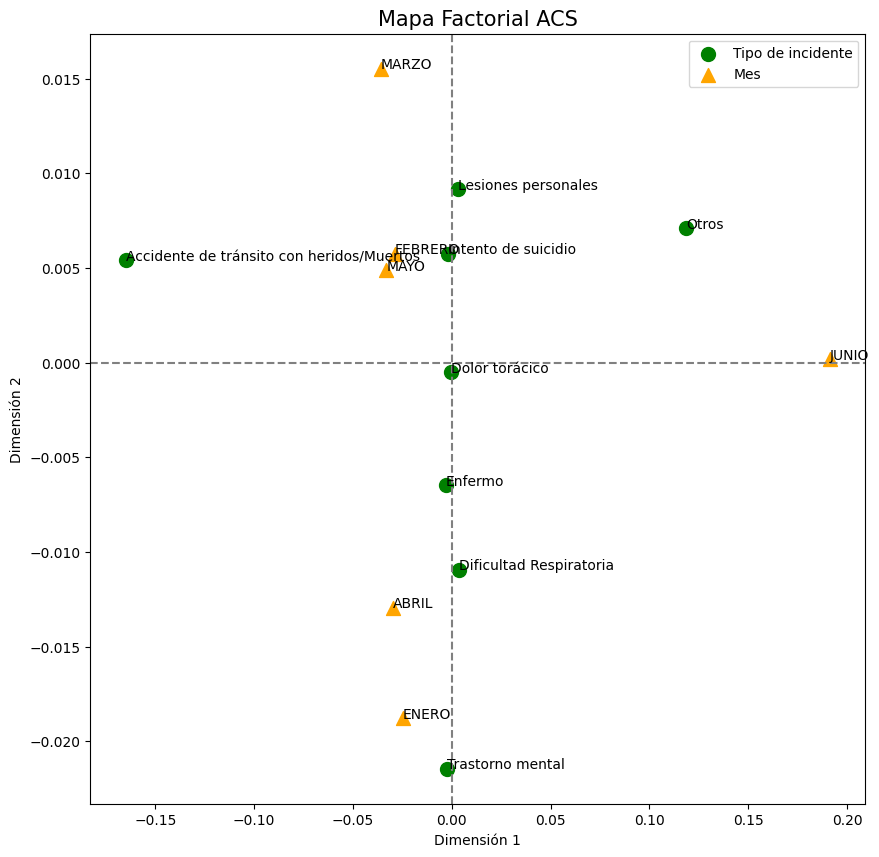

In [43]:
plt.figure(figsize=(10,10))
#Filas
plt.scatter(x=row_coords["Dim1"],y=row_coords["Dim2"],marker="o", s=100,label="Tipo de incidente",color="green")
for i in row_coords.index:
  plt.text(x=row_coords.loc[i,"Dim1"],
           y=row_coords.loc[i,"Dim2"],
           s=i,
           fontsize=10)
#columnas
plt.scatter(x=col_coords["Dim1"],y=col_coords["Dim2"],color="orange",s=100,marker="^",label="Mes")
for i in col_coords.index:
  plt.text(x=col_coords.loc[i,"Dim1"],
           y=col_coords.loc[i,"Dim2"],
           s=i,
           fontsize=10)
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Mapa Factorial ACS', fontsize=15)
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.legend()
plt.show()

La Figura presenta el mapa factorial del análisis de correspondencia simple aplicado. Las primeras dos dimensiones representan el 99.25% de la varianza acumulada de los datos, por lo cual, permite encontrar confiabilidad en los patrones.
Se identifica asociaciones entre Dificultad respiratoria y el mes de abril mostrando una relación de temporalidad basada en las condiciones climáticas. También se evidencia una relación entre el reporte por trastorno mental y enero, siendo significativamente mayor en este periodo de tiempo y luego de las fiestas y celebraciones familiares que se suelen realizar en el mes de diciembre; muestra también baja asociación a los meses de febrero, marzo y mayo. Sin embargo, también muestra asociación entre los meses de febrero y mayo con los intentos de suicidio pudiendo marcar un patrón para el periodo de tiempo esperado.
El dolor torácico al ubicarse cerca al origen no aporta gran diferencia e influencia en los datos. Los accidentes de tránsito no muestran relación particular con algún mes de los estudiados, Y finalmente el mes de junio muestra que aporta de manera significativa a la construcción del mes 2.


## **Paso 5: Análisis de correspondencia Múltiple:**

Se realizó un análisis de correspondencias múltiples (ACM) empleando las variables “Tipo de incidente agrupado”, “Clasificación final”, “Prioridad” y “Mes”. Las variables categóricas fueron codificadas mediante One-Hot Encoding para construir la matriz disyuntiva, sobre la cual se aplicó una descomposición truncada en valores singulares (SVD) con cinco componentes. Posteriormente, se calculó la inercia y la inercia acumulada de cada dimensión factorial.

In [44]:
variables = ['TIPO_INCIDENTE_AGRUPADO', "CLASIFICACION FINAL" ,"PRIORIDAD","MES"]
df_acm = pd.DataFrame(df_limpio[variables])

In [45]:
df_acm

,TIPO_INCIDENTE_AGRUPADO,CLASIFICACION FINAL,PRIORIDAD,MES
0,Lesiones personales,Cancelado,ALTA,ENERO
1,Accidente de tránsito con heridos/Muertos,Cancelado,ALTA,ENERO
2,Dolor torácico,Traslado,ALTA,ENERO
3,Otros,Falsa Alarma,ALTA,ENERO
4,Otros,Cancelado,ALTA,ENERO
...,...,...,...,...
127309,Dificultad Respiratoria,Desistimiento,ALTA,JUNIO
127310,Otros,Cancelado,ALTA,JUNIO
127311,Otros,Desistimiento,ALTA,JUNIO
127312,Intento de suicidio,Falsa Alarma,ALTA,JUNIO


In [46]:
encoder= OneHotEncoder(sparse_output=False) #Codificador para transformar variables categoricas en numericas binarias
#Sparse_output False #Se utiliza para que se guarde como matriz numpy y no como sparce matrix

X = encoder.fit_transform(df_acm)  #Creación de matriz disyuntiva
columnas=encoder.get_feature_names_out(df_acm.columns)
X = pd.DataFrame(X, columns=columnas)

In [47]:
n_factors=5 #Número de componentes

svd=TruncatedSVD(n_components=n_factors,random_state=0) #Creo el modelo svd truncado

coords_acm=svd.fit_transform(X.T) #Entreno el modelo y obtengo las coordenadas de cada variable en factores. Uso la transpuesta de matriz disyuntiva, para analizarlas columnas como observaciones
explained_acm =svd.explained_variance_ratio_ #Varianza explicada

orden = np.argsort(explained_acm)[::-1] #Ordeno las dimensiones de  mayor ra menor varianza
explaine_acm = explained_acm[orden] #Ordeno
coords_acm = coords_acm[:, orden] #Ordeno

inercia_acum=np.cumsum(explaine_acm) #Cálculo de inercia acumulada

columnas_dim_acm=[
    f"Dim{i+1}" for i in range(n_factors)]  #Genero el nombre de las columnas

#Creación del dataframe
coords_df=pd.DataFrame(coords_acm,index=X.columns,
                       columns=columnas_dim_acm)

In [48]:
coords_df

,Dim1,Dim2,Dim3,Dim4,Dim5
TIPO_INCIDENTE_AGRUPADO_Accidente de tránsito con heridos/Muertos,74.591448,-96.030703,-60.510152,14.781405,35.754369
TIPO_INCIDENTE_AGRUPADO_Dificultad Respiratoria,35.587961,-2.287690,-33.011047,-0.470744,-15.773001
TIPO_INCIDENTE_AGRUPADO_Dolor torácico,13.680888,-1.581533,-9.172911,-0.031365,-3.217198
TIPO_INCIDENTE_AGRUPADO_Enfermo,16.919051,24.577396,-21.034874,14.824018,44.056219
TIPO_INCIDENTE_AGRUPADO_Intento de suicidio,14.184840,-3.083902,-8.366506,-0.191184,-2.017393
TIPO_INCIDENTE_AGRUPADO_Lesiones personales,11.372479,-5.234784,-2.794410,1.527922,5.747648
TIPO_INCIDENTE_AGRUPADO_Otros,167.464519,72.794680,131.224640,-11.919431,-18.969349
TIPO_INCIDENTE_AGRUPADO_Trastorno mental,8.649035,21.010582,-14.586962,9.177115,24.506304
CLASIFICACION FINAL_Cancelado,74.523061,-52.914239,61.563168,27.633350,86.459946
CLASIFICACION FINAL_Desistimiento,19.592571,-7.557094,4.368405,-0.692569,2.288496


In [49]:
dimensiones_acm = pd.DataFrame({
    "Dimension": [f"Dim{i+1}" for i in range(len(explained_acm))],
    "Inertia explicada por factor(%)": explained_acm * 100,
    "Inercia acumulada": inercia_acum * 100})
dimensiones_acm

,Dimension,Inertia explicada por factor(%),Inercia acumulada
0,Dim1,26.329949,26.329949
1,Dim2,11.716300,38.046250
2,Dim3,8.409636,46.455885
3,Dim4,6.413586,53.222002
4,Dim5,6.766117,59.635589


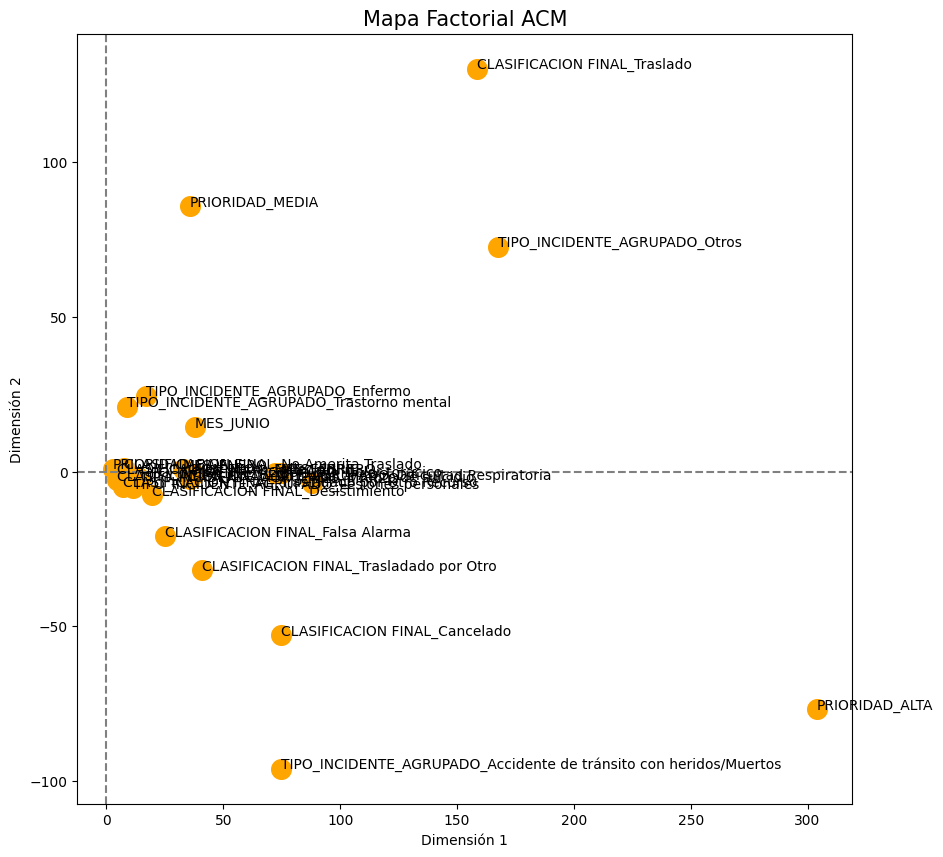

In [50]:
plt.figure(figsize=(10,10))

plt.scatter(x=coords_df["Dim1"],y=coords_df["Dim2"],s=200,color="orange")
for i in coords_df.index:
  plt.text(x=coords_df.loc[i,"Dim1"],
           y=coords_df.loc[i,"Dim2"],
           s=i,
           fontsize=10)

plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

plt.title('Mapa Factorial ACM', fontsize=15)

plt.xlabel("Dimensión 1")
plt.ylabel('Dimensión 2')
plt.show()


En la Figura se presenta el resultado del análisis de correspondencia múltiple. Para las variables analizadas, las primeras dos dimensiones representan el 38% de la inercia acumulada y por lo tanto las variables se observan muy cercanas (poca varianza).
Se identifica una asociación entre el mes de junio y los tipos de incidentes reportado como enfermos y trastorno mental, sin embargo, la asociación es factiblemente baja teniendo en cuenta la varianza acumulada baja. Se observa que la clasificación de las prioridades (Alta, media o baja) se encuentran muy dispersas y no muestran relación significativa con determinados tipos de incidentes o clasificación realizada al paciente. Esto puede indicar que los factores, situaciones y condiciones asociadas al tipo de incidente puede demarcar también la prioridad. Se observa que categorías como el paciente que es trasladado muestra gran diferenciación y poca asociación con las demás subcategorías. De igual manera el tipo de incidente agrupado.
